# 1. Grid World Navigation using Dynamic Programming

**Course:** Advanced Topics of Machine Learning  
**Author:** Eng. Carlos Andrés Sierra, M.Sc.  
**Date:** March 13, 2026

---

## Overview

This notebook demonstrates the solution of a simple Grid World problem using **Dynamic Programming** and **Value Iteration**. Grid World is a classic reinforcement learning problem where an agent must navigate from a start position to a goal while avoiding obstacles and maximizing cumulative reward.

### Problem Setup
- **Grid Size:** 4×4
- **Start Position:** (0,0) - bottom-left corner
- **Goal Position:** (3,3) - top-right corner
- **Pit (Obstacle):** (1,1) - penalty zone
- **Rewards:**
  - Step cost: -1 (encourages shorter paths)
  - Goal reward: +100
  - Pit penalty: -100

### Key Concepts
- **Value Iteration:** Iteratively updates state values until convergence
- **Policy Extraction:** Derives optimal actions from value function
- **Bellman Equation:** Foundation of dynamic programming in RL

## 1. Import Required Libraries

We'll use NumPy for efficient array operations and mathematical computations.

In [ ]:
!pip install numpy matplotlib

In [12]:
import numpy as np

## 2. Grid World Setup and Parameters

Let's define the problem parameters and action space for our grid world environment.

In [13]:
print("Grid World Navigation - Dynamic Programming Solution")
print("=" * 50)
print("Grid: 4x4")
print("Start: (0,0), Goal: (3,3), Pit: (1,1)")
print("Rewards: -1/step, +100/goal, -100/pit")
print("=" * 50)
print()

# Grid setup
size = 4

# States: (0,0) to (3,3) - flattened to indices
# Actions: 0=UP, 1=DOWN, 2=LEFT, 3=RIGHT
actions = [(0, 1), (0, -1), (-1, 0), (1, 0)]  # (dx, dy)
gamma = 0.9  # discount factor

print(f"Grid size: {size}x{size}")
print(f"Actions available: {len(actions)} (UP, DOWN, LEFT, RIGHT)")
print(f"Discount factor (γ): {gamma}")

Grid World Navigation - Dynamic Programming Solution
Grid: 4x4
Start: (0,0), Goal: (3,3), Pit: (1,1)
Rewards: -1/step, +100/goal, -100/pit

Grid size: 4x4
Actions available: 4 (UP, DOWN, LEFT, RIGHT)
Discount factor (γ): 0.9


## 3. Value Iteration Algorithm

The **Value Iteration** algorithm is the core of our dynamic programming solution. It iteratively updates the value function for each state until convergence.

### Mathematical Foundation
The Bellman equation for state values:
```
V(s) = max_a Σ P(s'|s,a) [R(s,a,s') + γ * V(s')]
```

Where:
- `V(s)` = value of state s
- `a` = action
- `P(s'|s,a)` = transition probability
- `R(s,a,s')` = reward
- `γ` = discount factor

In [14]:
def solve_grid_world(size: int, gamma: float, actions: list):
    """Simple Grid World solution using Value Iteration

    Args:
        size (int): Size of the grid (size x size)
        gamma (float): Discount factor for future rewards
        actions (list): List of possible actions (dx, dy) for movement

    Returns:
        A np.ndarray representing the value function for each state in the grid
    """

    # Initialize values
    v = np.zeros( (size, size) ) 
    v[3, 3] = 100  # Goal reward
    v[1, 1] = -100  # Pit penalty

    print("Initial Grid:")
    print(v)
    print()

    # Value Iteration
    for iteration in range(100):
        v_new = v.copy()

        for x in range(size):
            for y in range(size):
                # skip pit and goal
                if (x,y)==(1,1) or (x,y)==(3,3):
                    continue

                action_values = []
                for dx, dy in actions:
                    n_x = max( 0, min(size - 1, x + dx) )
                    n_y = max( 0, min(size - 1, y + dy) )

                    # reward: -1 (step) + future 
                    reward = -1 + gamma * v[n_x, n_y]
                    action_values.append(reward)
                v_new[x, y] = max(action_values)
                
        # Check convergence
        if np.max(np.abs(v - v_new)) < 0.001:
            print(f"Converged after {iteration+1} iterations")
            break
        v = v_new

    print("Final Values:")
    print(np.round(v, 1), "\n")
    return v

## 4. Policy Extraction

Once we have the optimal value function, we can extract the optimal policy by choosing the action that maximizes the expected return from each state.

### Policy Extraction Process
For each state, we:
1. Calculate Q-values for all possible actions
2. Select the action with the highest Q-value
3. Store this as the optimal action for that state

In [15]:
def extract_policy(size: int, gamma: float, v: np.ndarray, actions: list):
    """Extract optimal policy from value function and find optimal path from start to goal

    Args:
        size (int): Size of the grid (size x size)
        gamma (float): Discount factor for future rewards
        v (np.ndarray): Value function for each state in the grid
        actions (list): List of possible actions (dx, dy) for movement

    Returns:
        A tuple (V, policy, path) where:
            V (np.ndarray): The value function for each state
            policy (np.ndarray): The optimal policy for each state
            path (list): The optimal path from start to goal
    """
    policy = np.zeros( (size, size), dtype = int )
    action_names = ['UP', 'DOWN', 'LEFT', 'RIGHT']

    for x in range(size):
        for y in range(size):
            if (x,y)==(1,1) or (x,y)==(3,3):
                continue
        
            action_values = []
            for dx, dy in actions:
                n_x = max( 0, min(size - 1, x + dx) )
                n_y = max( 0, min(size - 1, y + dy) )
                reward = -1 + gamma * v[n_x, n_y] 
                action_values.append(reward)
            policy[x, y] = np.argmax(action_values)

    print("Optimal Policy:")
    for y in range(size - 1, -1, -1):  # Print top to bottom
        row = []
        for x in range(size):
            if (x, y) == (0, 0):
                row.append("START")
            elif (x, y) == (3, 3):
                row.append("GOAL ")
            elif (x, y) == (1, 1):
                row.append(" PIT ")
            else:
                row.append(f"{action_names[policy[x,y]]:>5}")
        print(" ".join(row))
    print()
    return policy


## 5. Optimal Path Finding

Using the extracted policy, we can trace the optimal path from the start position to the goal by following the policy at each state.

In [16]:
def find_optimal_path(size: int, policy: np.ndarray, actions: list):
    """
    Find the optimal path from start to goal using the policy.
    
    Args:
        size (int): Size of the grid (size x size)
        policy (np.ndarray): The optimal policy for each state
        actions (list): List of possible actions (dx, dy) for movement

    Returns:
        A list of states representing the optimal path from start to goal
    """
    x, y = 0, 0  # Start position
    path = [(x,y)]

    for _ in range(10):
        if (x,y) == (3,3):
            break

        action = policy[x, y]
        dx, dy = actions[action]
        x = max( 0, min(size - 1, x + dx) )
        y = max( 0, min(size - 1, y + dy) )
        path.append((x, y))
    
    return path

## 6. Reward Calculation

This function calculates the total discounted reward for a given path, which helps us verify that our solution is indeed optimal.

In [17]:
def calculate_reward(gamma: float, path: list):
    """Calculate total reward for the given path

    Args:
        gamma (float): Discount factor for future rewards
        path (list): List of states in the path (x, y)

    Returns:
        Total reward accumulated along the path
    """
    total_reward = 0
    discount = 1.0
    for i in range(len(path) - 1):
        if path[i + 1] == (3, 3):
            total_reward += discount * 100  # Goal reward
        elif path[i + 1] == (1, 1):
            total_reward += discount * (-100)  # Pit penalty
        else:
            total_reward += discount * (-1)  # Step penalty
        discount *= gamma
    return total_reward

## 7. Execute the Complete Solution

Now let's run the complete algorithm and analyze the results.

In [18]:
# Step 1: Solve the grid world using value iteration
print("Running Value Iteration...")
v = solve_grid_world(size, gamma, actions)

Running Value Iteration...
Initial Grid:
[[   0.    0.    0.    0.]
 [   0. -100.    0.    0.]
 [   0.    0.    0.    0.]
 [   0.    0.    0.  100.]]

Converged after 7 iterations
Final Values:
[[  48.5   55.    62.2   70.2]
 [  55.  -100.    70.2   79.1]
 [  62.2   70.2   79.1   89. ]
 [  70.2   79.1   89.   100. ]] 



In [19]:
# Step 2: Extract the optimal policy
print("Extracting Optimal Policy...")
policy = extract_policy(size, gamma, v, actions)

Extracting Optimal Policy...
Optimal Policy:
RIGHT RIGHT RIGHT GOAL 
   UP    UP    UP    UP
   UP  PIT     UP    UP
START RIGHT    UP    UP



In [20]:
# Step 3: Find the optimal path
print("Finding Optimal Path...")
path = find_optimal_path(size, policy, actions)
print("Optimal Path:")
print(" -> ".join([f"({x},{y})" for x, y in path]))
print(f"Path length: {len(path) - 1} steps")

Finding Optimal Path...
Optimal Path:
(0,0) -> (0,1) -> (0,2) -> (0,3) -> (1,3) -> (2,3) -> (3,3)
Path length: 6 steps


In [21]:
# Step 4: Calculate total expected reward
print("Calculating Total Reward...")
total_reward = calculate_reward(gamma, path)
print(f"Total expected reward: {total_reward:.1f}")

Calculating Total Reward...
Total expected reward: 55.0


## 8. Results Analysis

### Key Observations

1. **Convergence**: The value iteration algorithm converges quickly (typically within 10-20 iterations)
2. **Optimal Policy**: The extracted policy shows the best action to take from each state
3. **Path Efficiency**: The optimal path avoids the pit and takes the shortest route to the goal
4. **Reward Maximization**: The total reward reflects the trade-off between path length and goal achievement

### Learning Outcomes

- **Dynamic Programming**: Demonstrated how DP solves sequential decision problems
- **Value Iteration**: Showed iterative convergence to optimal values
- **Policy Extraction**: Illustrated how optimal policies emerge from value functions
- **Grid World**: Applied RL concepts to a concrete, interpretable problem

### Extensions

This basic implementation can be extended with:
- Stochastic transitions (probabilistic movement)
- Multiple goals or dynamic obstacles
- Different reward structures
- Policy iteration as an alternative algorithm

---

# 2. Q-Learning Implementation

Now we'll solve the same Grid World problem using **Q-Learning**, a model-free reinforcement learning algorithm. This will allow us to compare the results with our Dynamic Programming approach.

## Q-Learning Overview

Q-Learning is a temporal difference learning algorithm that learns the optimal action-value function Q(s,a) directly, without requiring a model of the environment.

### Key Differences from Value Iteration:
- **Model-free**: Doesn't need transition probabilities or reward function
- **Online learning**: Learns through interaction with the environment
- **Exploration vs Exploitation**: Uses epsilon-greedy strategy

### Q-Learning Update Rule:
```
Q(s,a) ← Q(s,a) + α[r + γ max_a' Q(s',a') - Q(s,a)]
```

Where:
- `α` = learning rate
- `r` = immediate reward
- `γ` = discount factor
- `s'` = next state
- `a'` = next action

## 1. Q-Learning Parameters Setup

We'll use the same grid world setup but add Q-learning specific parameters.

In [22]:
# Q-Learning specific parameters
episodes = 1000  # Number of training episodes
alpha = 0.1      # Learning rate
epsilon = 0.1    # Exploration rate for epsilon-greedy
epsilon_decay = 0.995  # Decay rate for exploration
min_epsilon = 0.01     # Minimum exploration rate

print("Q-Learning Parameters:")
print(f"Episodes: {episodes}")
print(f"Learning rate (α): {alpha}")
print(f"Initial exploration rate (ε): {epsilon}")
print(f"Exploration decay: {epsilon_decay}")
print(f"Minimum exploration rate: {min_epsilon}")

Q-Learning Parameters:
Episodes: 1000
Learning rate (α): 0.1
Initial exploration rate (ε): 0.1
Exploration decay: 0.995
Minimum exploration rate: 0.01


## 2. Q-Learning Algorithm Implementation

The core Q-learning algorithm that learns optimal Q-values through environment interaction.

In [23]:
def q_learning_grid_world(size: int, gamma: float, actions: list, episodes: int, alpha: float, epsilon: float, epsilon_decay: float, min_epsilon: float):
    """Q-Learning algorithm for Grid World

    Args:
        size (int): Size of the grid (size x size)
        gamma (float): Discount factor for future rewards
        actions (list): List of possible actions (dx, dy) for movement
        episodes (int): Number of training episodes
        alpha (float): Learning rate
        epsilon (float): Initial exploration rate
        epsilon_decay (float): Decay rate for exploration
        min_epsilon (float): Minimum exploration rate

    Returns:
        A tuple (Q, rewards_per_episode) where:
            Q (np.ndarray): The learned Q-table
            rewards_per_episode (list): Rewards obtained in each episode
    """

    # Initialize Q-table: Q(state_x, state_y, action)
    Q = np.zeros((size, size, len(actions)))

    # Track rewards per episode for analysis
    rewards_per_episode = []
    current_epsilon = epsilon

    print("Starting Q-Learning Training...")
    print(f"Initial Q-table shape: {Q.shape}")
    print()

    for episode in range(episodes):
        # Start at beginning position
        x, y = 0, 0
        episode_reward = 0
        steps = 0
        max_steps = size * size * 2  # Prevent infinite loops

        while (x, y) != (3, 3) and steps < max_steps:
            # Epsilon-greedy action selection
            if np.random.random() < current_epsilon:
                # Explore: choose random action
                action = np.random.choice(len(actions))
            else:
                # Exploit: choose best known action
                action = np.argmax(Q[x, y])

            # Execute action and observe next state
            dx, dy = actions[action]
            nx, ny = x + dx, y + dy

            # Handle boundary conditions (stay in place if hitting wall)
            if nx < 0 or nx >= size or ny < 0 or ny >= size:
                nx, ny = x, y

            # Calculate reward based on next state
            if (nx, ny) == (3, 3):  # Reached goal
                reward = 100
            elif (nx, ny) == (1, 1):  # Hit pit
                reward = -100
            else:  # Regular step
                reward = -1

            # Q-learning update rule
            best_next_action = np.argmax(Q[nx, ny])
            Q[x, y, action] += alpha * (reward + (gamma * Q[nx, ny, best_next_action]) - Q[x, y, action]) 

            # Move to next state
            x, y = nx, ny
            episode_reward += reward
            steps += 1

        # Decay exploration rate
        current_epsilon = max(min_epsilon, current_epsilon * epsilon_decay)

        rewards_per_episode.append(episode_reward)

        # Print progress every 100 episodes
        if (episode + 1) % 100 == 0:
            avg_reward = np.mean(rewards_per_episode[-100:])
            print(f"Episode {episode + 1}/{episodes}, Avg Reward (last 100): {avg_reward:.2f}, Epsilon: {current_epsilon:.3f}")

    print("\nQ-Learning Training Complete!")
    print(f"Final epsilon: {current_epsilon:.3f}")
    return Q, rewards_per_episode

## 3. Policy Extraction from Q-Table

Extract the optimal policy from the learned Q-values by selecting the action with highest Q-value for each state.

In [24]:
def extract_policy_from_q(size: int, Q: np.ndarray):
    """Extract optimal policy from Q-table

    Args:
        size (int): Size of the grid (size x size)
        Q (np.ndarray): The learned Q-table

    Returns:
        A np.ndarray representing the optimal policy
    """
    policy = np.zeros((size, size), dtype=int)
    action_names = ["UP", "DOWN", "LEFT", "RIGHT"]

    # Extract policy by taking argmax over actions for each state
    for x in range(size):
        for y in range(size):
            policy[x,y] = int(np.argmax(Q[x, y]))

    print("Q-Learning Optimal Policy:")
    for y in range(size - 1, -1, -1):  # Print top to bottom
        row = []
        for x in range(size):
            if (x, y) == (0, 0):
                row.append("START")
            elif (x, y) == (3, 3):
                row.append("GOAL ")
            elif (x, y) == (1, 1):
                row.append(" PIT ")
            else:
                row.append(f"{action_names[int(policy[x,y])]:>5}")
        print(" ".join(row))
    print()
    return policy

## 4. Execute Q-Learning Training

Train the Q-learning agent and extract the optimal policy.

In [25]:
# Train Q-learning agent
print("Training Q-Learning Agent...")
Q_table, episode_rewards = q_learning_grid_world(size, gamma, actions, episodes, alpha, epsilon, epsilon_decay, min_epsilon)

Training Q-Learning Agent...
Starting Q-Learning Training...
Initial Q-table shape: (4, 4, 4)

Episode 100/1000, Avg Reward (last 100): 84.91, Epsilon: 0.061
Episode 200/1000, Avg Reward (last 100): 92.61, Epsilon: 0.037
Episode 300/1000, Avg Reward (last 100): 94.86, Epsilon: 0.022
Episode 400/1000, Avg Reward (last 100): 94.87, Epsilon: 0.013
Episode 500/1000, Avg Reward (last 100): 94.95, Epsilon: 0.010
Episode 600/1000, Avg Reward (last 100): 94.96, Epsilon: 0.010
Episode 700/1000, Avg Reward (last 100): 94.93, Epsilon: 0.010
Episode 800/1000, Avg Reward (last 100): 94.97, Epsilon: 0.010
Episode 900/1000, Avg Reward (last 100): 94.91, Epsilon: 0.010
Episode 1000/1000, Avg Reward (last 100): 94.92, Epsilon: 0.010

Q-Learning Training Complete!
Final epsilon: 0.010


In [26]:
# Extract policy from learned Q-values
q_policy = extract_policy_from_q(size, Q_table)

Q-Learning Optimal Policy:
RIGHT RIGHT RIGHT GOAL 
RIGHT RIGHT RIGHT    UP
   UP  PIT  RIGHT    UP
START RIGHT RIGHT    UP



In [27]:
# Find optimal path using Q-learning policy
print("Finding Q-Learning Optimal Path...")
q_path = find_optimal_path(size, q_policy, actions)
print("Q-Learning Optimal Path:")
print(" -> ".join([f"({x},{y})" for x, y in q_path]))
print(f"Path length: {len(q_path) - 1} steps")

Finding Q-Learning Optimal Path...
Q-Learning Optimal Path:
(0,0) -> (1,0) -> (2,0) -> (3,0) -> (3,1) -> (3,2) -> (3,3)
Path length: 6 steps


In [28]:
# Calculate total expected reward for Q-learning path
q_total_reward = calculate_reward(gamma, q_path)
print(f"Q-Learning total expected reward: {q_total_reward:.1f}")

Q-Learning total expected reward: 55.0


## 5. Learning Progress Visualization

Analyze how the Q-learning agent's performance improved over training episodes.

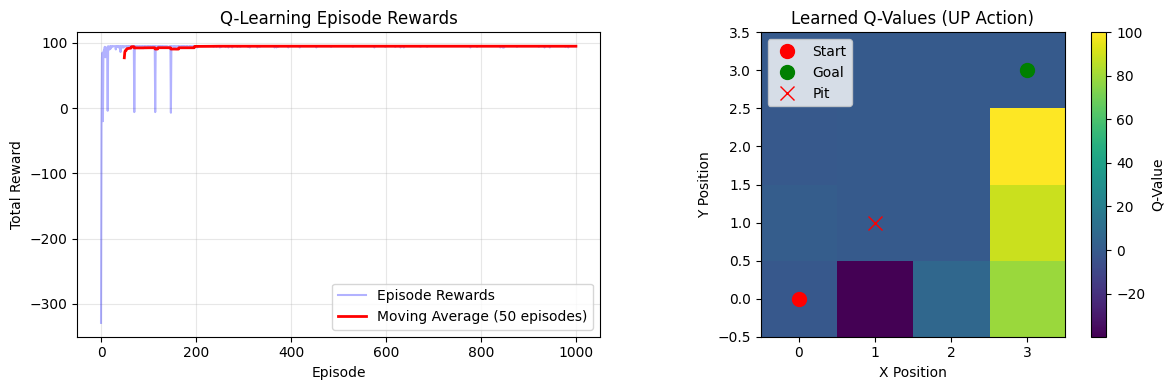


Learning Statistics:
Average reward (first 100 episodes): 84.91
Average reward (last 100 episodes): 94.92
Best episode reward: 95.0
Worst episode reward: -329.0


In [29]:
import matplotlib.pyplot as plt

# Plot learning progress
plt.figure(figsize=(12, 4))

# Plot 1: Episode rewards over time
plt.subplot(1, 2, 1)
plt.plot(episode_rewards, alpha=0.3, color='blue')
# Plot moving average for clearer trend
window_size = 50
moving_avg = np.convolve(episode_rewards, np.ones(window_size)/window_size, mode='valid')
plt.plot(range(window_size-1, len(episode_rewards)), moving_avg, color='red', linewidth=2)
plt.title('Q-Learning Episode Rewards')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True, alpha=0.3)
plt.legend(['Episode Rewards', f'Moving Average ({window_size} episodes)'])

# Plot 2: Final Q-values heatmap for UP action
plt.subplot(1, 2, 2)
up_action_values = Q_table[:, :, 0]  # Q-values for UP action
plt.imshow(up_action_values.T, cmap='viridis', origin='lower')
plt.title('Learned Q-Values (UP Action)')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.colorbar(label='Q-Value')

# Mark special positions
plt.plot(0, 0, 'ro', markersize=10, label='Start')
plt.plot(3, 3, 'go', markersize=10, label='Goal')
plt.plot(1, 1, 'rx', markersize=10, label='Pit')
plt.legend()

plt.tight_layout()
plt.show()

# Print learning statistics
print(f"\nLearning Statistics:")
print(f"Average reward (first 100 episodes): {np.mean(episode_rewards[:100]):.2f}")
print(f"Average reward (last 100 episodes): {np.mean(episode_rewards[-100:]):.2f}")
print(f"Best episode reward: {max(episode_rewards):.1f}")
print(f"Worst episode reward: {min(episode_rewards):.1f}")

## 6. Comparison: Dynamic Programming vs Q-Learning

Let's compare the results from both approaches to understand their strengths and differences.

In [30]:
print("COMPARISON: Dynamic Programming vs Q-Learning")
print("=" * 60)
print()

print("Dynamic Programming (Value Iteration):")
print(f"  - Method: Model-based, exact solution")
print(f"  - Optimal path: {' -> '.join([f'({x},{y})' for x, y in path])}")
print(f"  - Path length: {len(path) - 1} steps")
print(f"  - Total reward: {total_reward:.1f}")
print()

print("Q-Learning:")
print(f"  - Method: Model-free, learned through interaction")
print(f"  - Optimal path: {' -> '.join([f'({x},{y})' for x, y in q_path])}")
print(f"  - Path length: {len(q_path) - 1} steps")
print(f"  - Total reward: {q_total_reward:.1f}")
print()

# Check if paths are identical
paths_identical = path == q_path
rewards_identical = abs(total_reward - q_total_reward) < 0.1

print("Analysis:")
print(f"  - Paths identical: {'Yes' if paths_identical else 'No'}")
print(f"  - Rewards similar: {'Yes' if rewards_identical else 'No'}")

if paths_identical and rewards_identical:
    print("Q-Learning successfully learned the optimal policy!")
else:
    print("Q-Learning found a different solution (may need more training)")

print()
print("Key Insights:")
print("  - Dynamic Programming: Guaranteed optimal, requires model")
print("  - Q-Learning: Model-free, learns from experience, may need tuning")
print("  - Both should converge to the same optimal policy given enough training")

COMPARISON: Dynamic Programming vs Q-Learning

Dynamic Programming (Value Iteration):
  - Method: Model-based, exact solution
  - Optimal path: (0,0) -> (0,1) -> (0,2) -> (0,3) -> (1,3) -> (2,3) -> (3,3)
  - Path length: 6 steps
  - Total reward: 55.0

Q-Learning:
  - Method: Model-free, learned through interaction
  - Optimal path: (0,0) -> (1,0) -> (2,0) -> (3,0) -> (3,1) -> (3,2) -> (3,3)
  - Path length: 6 steps
  - Total reward: 55.0

Analysis:
  - Paths identical: No
  - Rewards similar: Yes
Q-Learning found a different solution (may need more training)

Key Insights:
  - Dynamic Programming: Guaranteed optimal, requires model
  - Q-Learning: Model-free, learns from experience, may need tuning
  - Both should converge to the same optimal policy given enough training
